
# Spotify Track Popularity Analysis
# Data Analyst Portfolio Project
# Author: Mallika Chand
# Tool: Python, Jupyter Notebook




## SECTION 0: LIBRARIES

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score)
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

print("Libraries loaded successfully")

Libraries loaded successfully


## SECTION 1: DATA LOADING

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
high = pd.read_csv('/content/drive/MyDrive/Spotify Analysis/data/high_popularity_spotify_data.csv')
low = pd.read_csv('/content/drive/MyDrive/Spotify Analysis/data/low_popularity_spotify_data.csv')

# Add popularity tier label
high["popularity_tier"] = "high"
low["popularity_tier"] = "low"

# Combine datasets
df = pd.concat([high, low], ignore_index=True)
df_copy = df.copy()

print("High popularity shape:", high.shape)
print("Low popularity shape:", low.shape)
print("Combined shape:", df.shape)
df.head()

High popularity shape: (1686, 30)
Low popularity shape: (3145, 30)
Combined shape: (4831, 30)


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,popularity_tier
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high


## SECTION 2: DATA PREPROCESSING (EDA)

In [4]:
df.head(10)

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,popularity_tier
0,0.592,157.969,0.521,pop,-7.777,0.1220,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
1,0.507,104.978,0.747,pop,-10.171,0.1170,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
2,0.808,108.548,0.554,pop,-4.169,0.1590,0.372,Gracie Abrams,4.0,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
3,0.910,112.966,0.670,pop,-4.070,0.3040,0.786,Sabrina Carpenter,4.0,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
4,0.783,149.027,0.777,pop,-4.477,0.3550,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
5,0.582,116.712,0.700,pop,-5.960,0.0881,0.785,Chappell Roan,4.0,0.0356,...,1WAjjRMfZjEXtB0lQrAw6Q,0.0,11.0,218424.0,0.0502,0WbMK4wrZ1wFSty9F7FCgu,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
6,0.561,150.069,0.669,pop,-6.538,0.0954,0.841,Addison Rae,4.0,0.0411,...,0XA403JTounqFh2owquBXu,1.0,10.0,169698.0,0.4950,6MzofobZt2dm0Kf1hTThFz,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
7,0.247,148.101,0.467,pop,-12.002,0.1700,0.126,Billie Eilish,4.0,0.0431,...,7aJuG4TFXa2hmE4z1yxc3n,0.0,6.0,261467.0,0.6120,3QaPy1KgI7nu9FJEQUgn6h,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
8,0.416,94.926,0.492,pop,-10.439,0.2030,0.297,Gigi Perez,4.0,0.0254,...,4DWrYvfGXRE8ko5ZxlIpit,1.0,11.0,211979.0,0.6860,0UYnhUfnUj5adChuAXvLUB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high
9,0.722,119.973,0.769,pop,-5.485,0.1110,0.570,"The Weeknd, Playboi Carti",4.0,0.0507,...,2IRxVVqbSbqHJo8Zx50LYn,0.0,11.0,256000.0,0.0584,1Es7AUAhQvapIcoh3qMKDL,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,high


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   energy                    4830 non-null   float64
 1   tempo                     4830 non-null   float64
 2   danceability              4830 non-null   float64
 3   playlist_genre            4831 non-null   object 
 4   loudness                  4830 non-null   float64
 5   liveness                  4830 non-null   float64
 6   valence                   4830 non-null   float64
 7   track_artist              4831 non-null   object 
 8   time_signature            4830 non-null   float64
 9   speechiness               4830 non-null   float64
 10  track_popularity          4831 non-null   int64  
 11  track_href                4830 non-null   object 
 12  uri                       4830 non-null   object 
 13  track_album_name          4830 non-null   object 
 14  playlist

###Checking Missing Values

In [6]:
df_model = df[["energy", "tempo", "danceability",
               "valence", "loudness", "acousticness",
               "speechiness", "instrumentalness",
               "liveness", "track_popularity",
               "playlist_genre", "popularity_tier"]].copy()

df_model.isnull().sum()

,0
energy,1
tempo,1
danceability,1
valence,1
loudness,1
acousticness,1
speechiness,1
instrumentalness,1
liveness,1
track_popularity,0


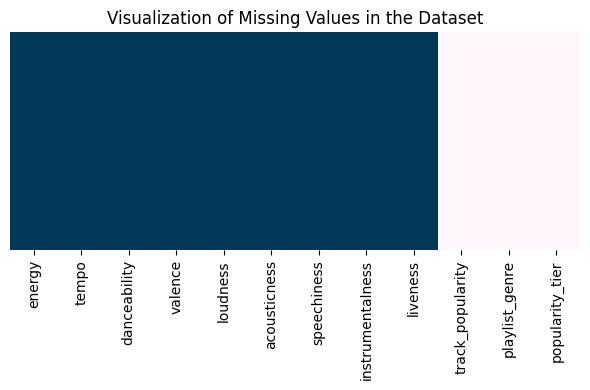

Rows with missing values: 1


In [7]:
plt.figure(figsize=(6, 4))
null_rows = df_model[df_model.isnull().any(axis=1)]
sns.heatmap(null_rows.isnull(), yticklabels=False, cbar=False, cmap='PuBu')
plt.title("Visualization of Missing Values in the Dataset")
plt.tight_layout()
plt.show()

print(f"Rows with missing values: {null_rows.shape[0]}")

The heatmap shows that all 9 audio feature columns have 1 missing value each, all from the same row. The remaining 3 columns track_popularity, playlist_genre and popularity_tier are completely clean. Since only 1 row out of 4831 is affected, we can safely drop it.

In [8]:
df_model = df_model.dropna()
print("After dropping nulls:", df_model.shape)

After dropping nulls: (4830, 12)


###Outliers Detection

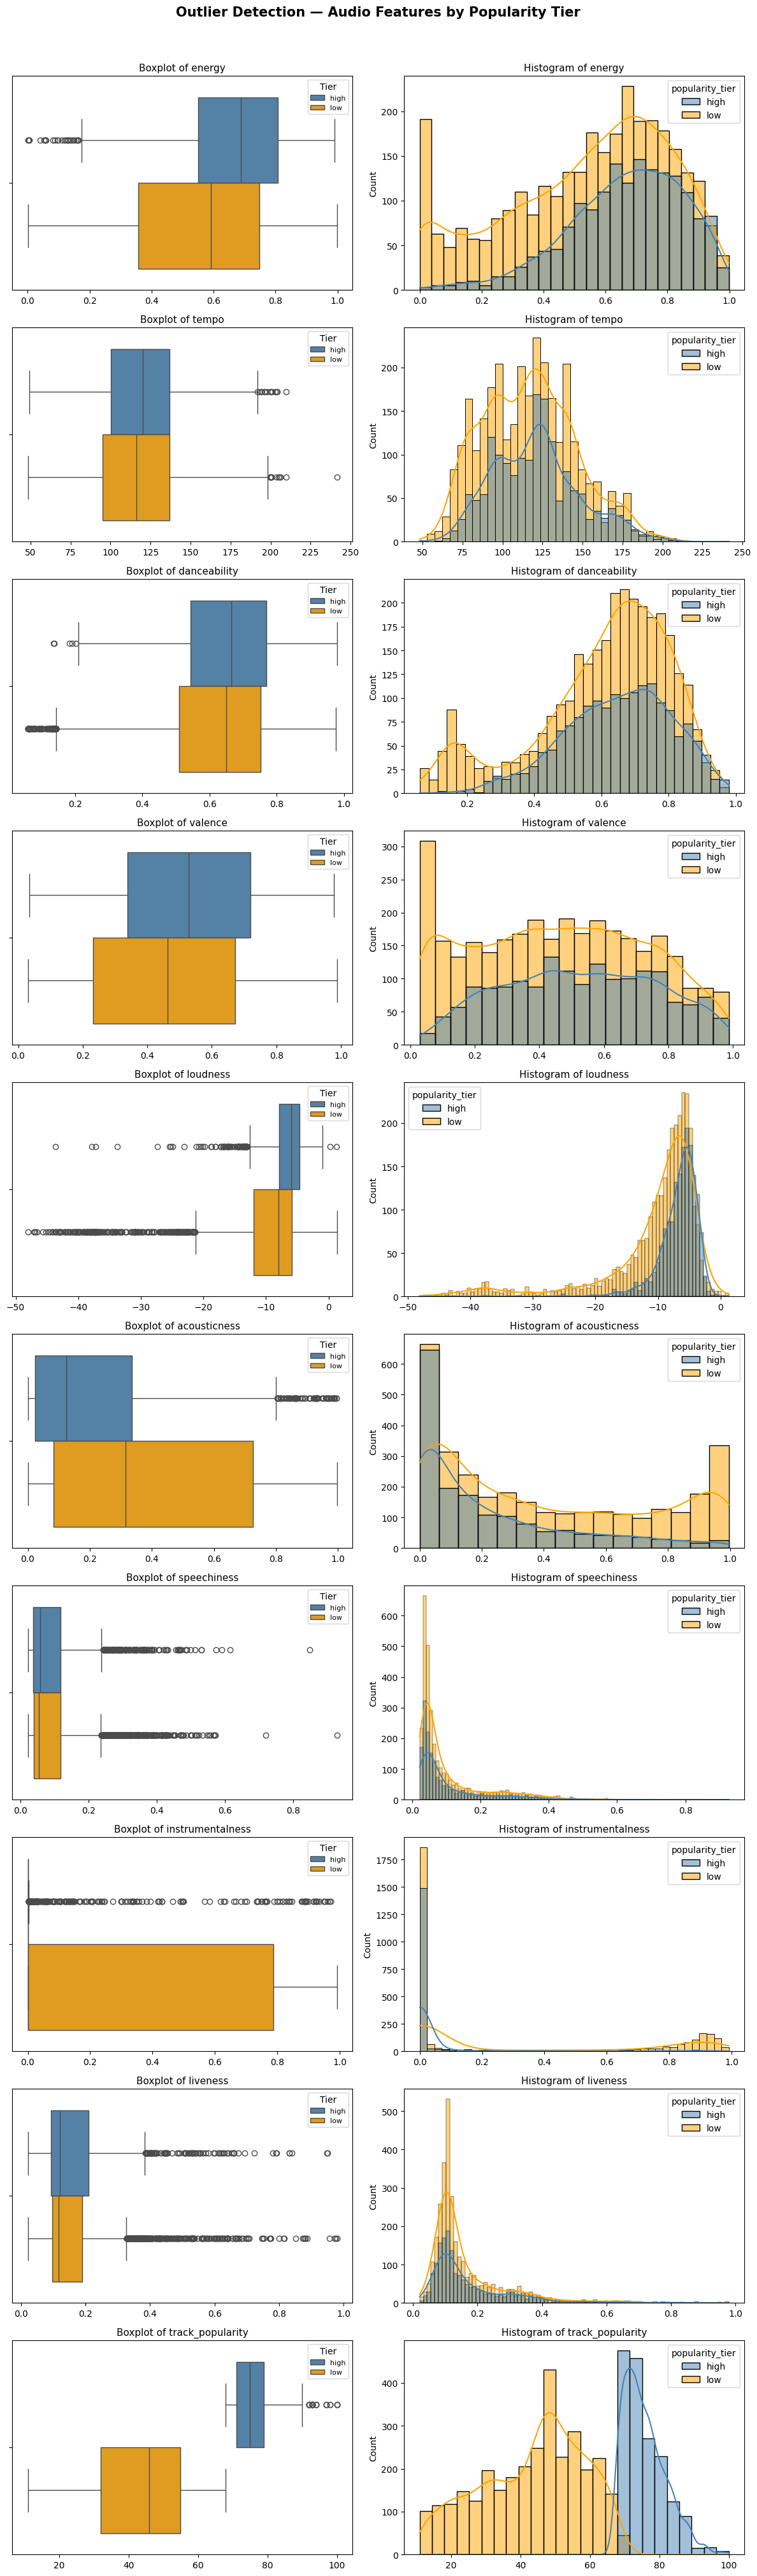

In [9]:
numeric_cols = df_model.select_dtypes(include=['float64', 'int64']).columns

fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2,
                         figsize=(12, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Boxplot
    sns.boxplot(ax=axes[i, 0], x=df_model[col],
                hue=df_model["popularity_tier"],
                palette={"high": "steelblue", "low": "orange"})
    axes[i, 0].set_title(f"Boxplot of {col}", fontsize=11)
    axes[i, 0].legend(title="Tier", loc="upper right", fontsize=8)
    axes[i, 0].set_xlabel("")

    # Histogram + KDE
    sns.histplot(ax=axes[i, 1], x=df_model[col],
                 hue=df_model["popularity_tier"],
                 kde=True,
                 palette={"high": "steelblue", "low": "orange"})
    axes[i, 1].set_title(f"Histogram of {col}", fontsize=11)
    axes[i, 1].set_xlabel("")

fig.suptitle("Outlier Detection — Audio Features by Popularity Tier",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("outliers.png", dpi=150, bbox_inches="tight")
plt.show()

* Energy — High popularity songs (blue) are more energetic than low popularity ones (orange). The histogram shows high popularity tracks cluster towards higher energy values.
* Tempo — Both tiers have similar tempo distributions. The difference is small — speed doesn't matter as much as energy.
* Danceability — High popularity tracks are slightly more danceable. Low popularity tracks are more spread out across the range.
* Valence — High popularity songs tend to be happier and more positive. Low popularity songs are more spread across all moods.
* Loudness — High popularity tracks are significantly louder (closer to 0 dB). Low popularity tracks have a longer tail towards very quiet values (-40 to -50 dB).
* Acousticness — The biggest visual difference. High popularity tracks cluster near 0 (not acoustic). Low popularity tracks are spread across the full range including very high acoustic values.
* Speechiness — Both tiers are mostly low speechiness. A few outliers exist with high speechiness — likely spoken word or rap tracks.
* Instrumentalness — Most tracks have near zero instrumentalness. Low popularity has more outliers with high instrumentalness — instrumental tracks tend to perform worse.
* Liveness — Both tiers cluster near 0 meaning most tracks are studio recorded not live. A few outliers exist in both.
* Track Popularity — The clearest separation. High popularity tracks (blue) cluster between 68 and 100. Low popularity tracks (orange) cluster between 11 and 68. Clean split confirming our two groups are well defined.

The boxplots and histograms show outliers across several audio features. Speechiness and instrumentalness have the most outliers in both tiers. Loudness has a long left tail with some tracks going below -40 dB. Track popularity shows a clean separation between high and low tiers confirming our two groups are well defined.

###Checking Duplicates

In [10]:
duplicate_count = df_model.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
df_model[df_model.duplicated()]

Number of duplicate rows: 112


,energy,tempo,danceability,valence,loudness,acousticness,speechiness,instrumentalness,liveness,track_popularity,playlist_genre,popularity_tier
180,0.4720,101.061,0.898,0.2140,-7.001,0.0107,0.0776,0.000000,0.1410,88,hip-hop,high
182,0.5520,144.941,0.640,0.1120,-5.679,0.0215,0.1290,0.000000,0.1190,84,hip-hop,high
220,0.4340,150.062,0.833,0.2810,-8.795,0.0102,0.4310,0.021900,0.1650,81,hip-hop,high
226,0.4130,131.964,0.772,0.2110,-8.194,0.0361,0.0891,0.000000,0.1110,77,hip-hop,high
248,0.5830,116.624,0.709,0.5330,-5.298,0.1380,0.2040,0.000003,0.1950,79,hip-hop,high
...,...,...,...,...,...,...,...,...,...,...,...,...
3862,0.6880,112.891,0.772,0.7850,-9.390,0.2010,0.1030,0.000258,0.2740,57,gospel,low
3870,0.6240,143.853,0.464,0.4810,-4.771,0.8300,0.0617,0.000002,0.1440,55,gospel,low
4045,0.3410,105.513,0.701,0.1630,-12.260,0.4990,0.0418,0.903000,0.3590,62,classical,low
4049,0.0217,104.541,0.278,0.2230,-37.438,0.9800,0.0327,0.919000,0.0926,61,classical,low


112 duplicate rows were found where all 12 columns are identical. These are true duplicates where the same song appears in multiple playlists with the same audio features. We will drop these to avoid bias in our analysis and machine learning model.

In [11]:
df_model = df_model.drop_duplicates()
print("After dropping duplicates:", df_model.shape)

After dropping duplicates: (4718, 12)


###Anomalies Detection

In [12]:
df_model.describe()

,energy,tempo,danceability,valence,loudness,acousticness,speechiness,instrumentalness,liveness,track_popularity
count,4718.000000,4718.000000,4718.000000,4718.000000,4718.000000,4718.000000,4718.000000,4718.000000,4718.000000,4718.000000
mean,0.584173,118.276491,0.622409,0.481056,-9.334061,0.345003,0.101960,0.204211,0.167537,54.236117
std,0.246837,28.596345,0.187820,0.258482,7.171860,0.326022,0.101329,0.354177,0.124280,19.702370
min,0.000202,48.232000,0.058900,0.029600,-48.069000,0.000004,0.021900,0.000000,0.021000,11.000000
25%,0.438000,96.037250,0.525000,0.272250,-10.386000,0.055825,0.038600,0.000000,0.095500,40.250000
50%,0.631000,118.133500,0.654000,0.482000,-7.224500,0.229500,0.056050,0.000090,0.117500,55.000000
75%,0.774000,137.012250,0.757750,0.689750,-5.353500,0.601000,0.118000,0.227250,0.195750,71.000000
max,0.998000,241.426000,0.979000,0.987000,1.318000,0.996000,0.927000,0.991000,0.979000,100.000000


All statistics are within reasonable ranges. Energy, danceability, valence, acousticness, speechiness, liveness and instrumentalness all fall between 0 and 1 as expected. Loudness is negative as expected since it is measured in decibels where 0 dB is maximum volume. One minor anomaly is the max loudness value of 1.318 dB which is slightly above 0, likely due to audio normalization during mastering. This does not significantly affect our analysis.

###PDF (Probability Density Function)

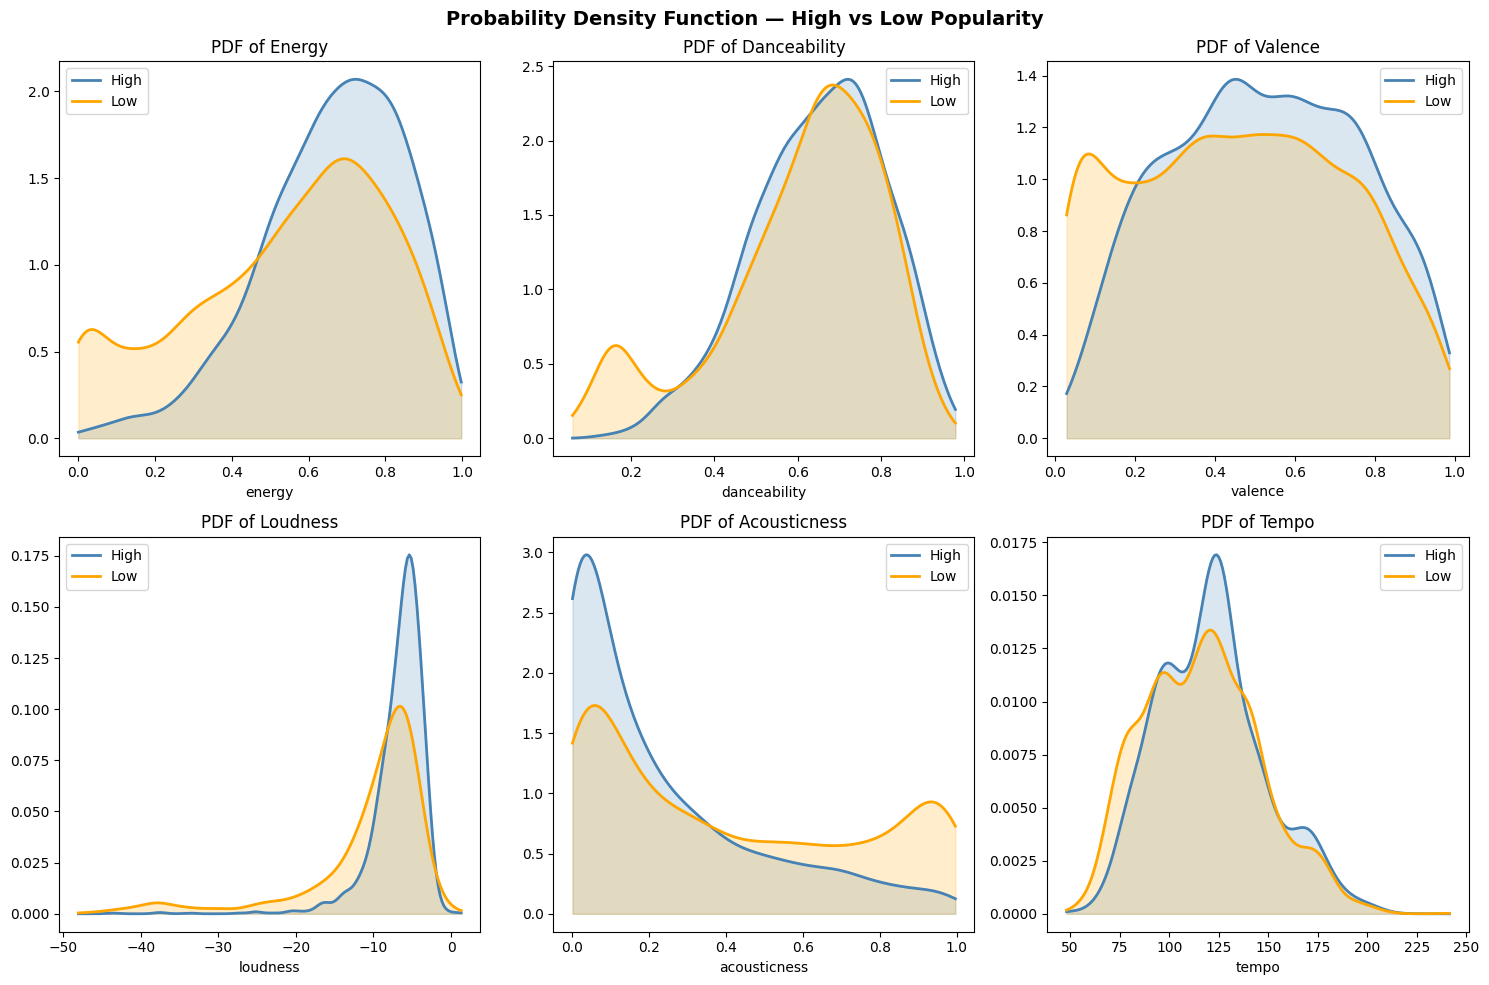

In [13]:
features_pdf = ["energy", "danceability", "valence",
                "loudness", "acousticness", "tempo"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, feature in enumerate(features_pdf):
    ax = axes[i//3][i%3]

    high_data = df_model[df_model["popularity_tier"]=="high"][feature].dropna()
    low_data = df_model[df_model["popularity_tier"]=="low"][feature].dropna()

    high_kde = gaussian_kde(high_data)
    low_kde = gaussian_kde(low_data)

    x_range = np.linspace(
        min(high_data.min(), low_data.min()),
        max(high_data.max(), low_data.max()), 200)

    ax.plot(x_range, high_kde(x_range),
            label="High", color="steelblue", linewidth=2)
    ax.plot(x_range, low_kde(x_range),
            label="Low", color="orange", linewidth=2)
    ax.fill_between(x_range, high_kde(x_range), alpha=0.2, color="steelblue")
    ax.fill_between(x_range, low_kde(x_range), alpha=0.2, color="orange")
    ax.set_title(f"PDF of {feature.capitalize()}")
    ax.set_xlabel(feature)
    ax.legend()

plt.suptitle("Probability Density Function — High vs Low Popularity",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("pdf_analysis.png", dpi=150)
plt.show()

Energy, loudness and acousticness show the clearest separation between popular and unpopular songs. Danceability, valence and tempo look similar for both groups.

###CDF (Cumulative Distribution Function)

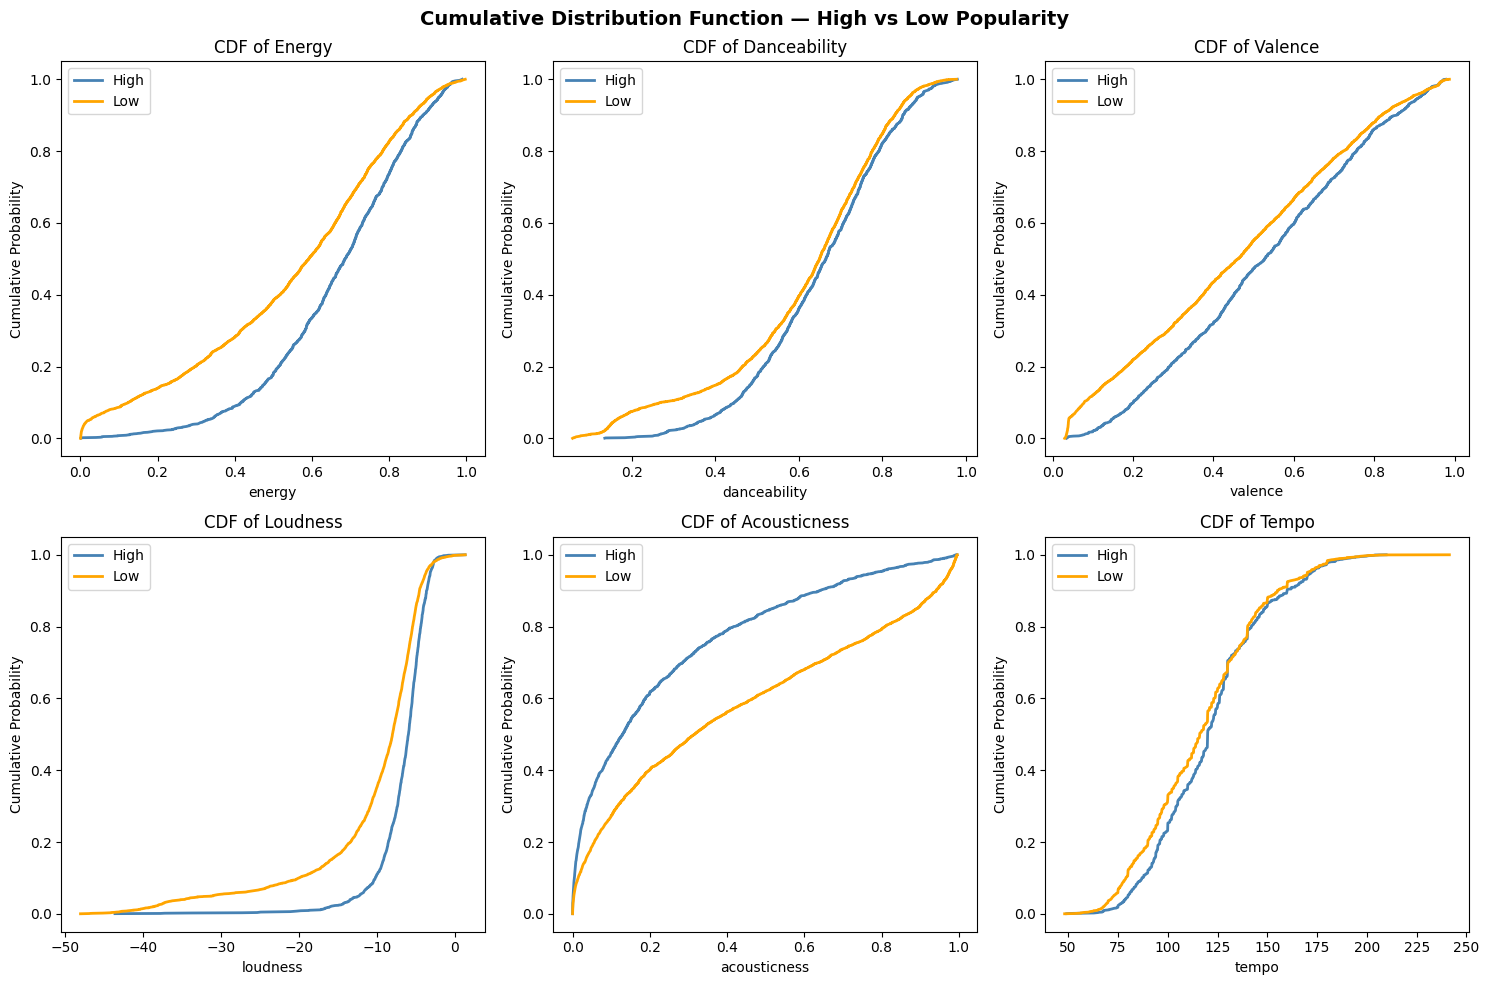

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, feature in enumerate(features_pdf):
    ax = axes[i//3][i%3]

    high_data = df_model[df_model["popularity_tier"]=="high"][feature].dropna().sort_values()
    low_data = df_model[df_model["popularity_tier"]=="low"][feature].dropna().sort_values()

    ax.plot(high_data,
            np.arange(1, len(high_data)+1) / len(high_data),
            label="High", color="steelblue", linewidth=2)
    ax.plot(low_data,
            np.arange(1, len(low_data)+1) / len(low_data),
            label="Low", color="orange", linewidth=2)

    ax.set_title(f"CDF of {feature.capitalize()}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Cumulative Probability")
    ax.legend()

plt.suptitle("Cumulative Distribution Function — High vs Low Popularity",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("cdf_analysis.png", dpi=150)
plt.show()

The CDF confirms the PDF findings. Acousticness, loudness and energy are the three features that most clearly separate popular from unpopular songs. Tempo, danceability and valence show little difference between the two tiers.

###Correlation Heatmap

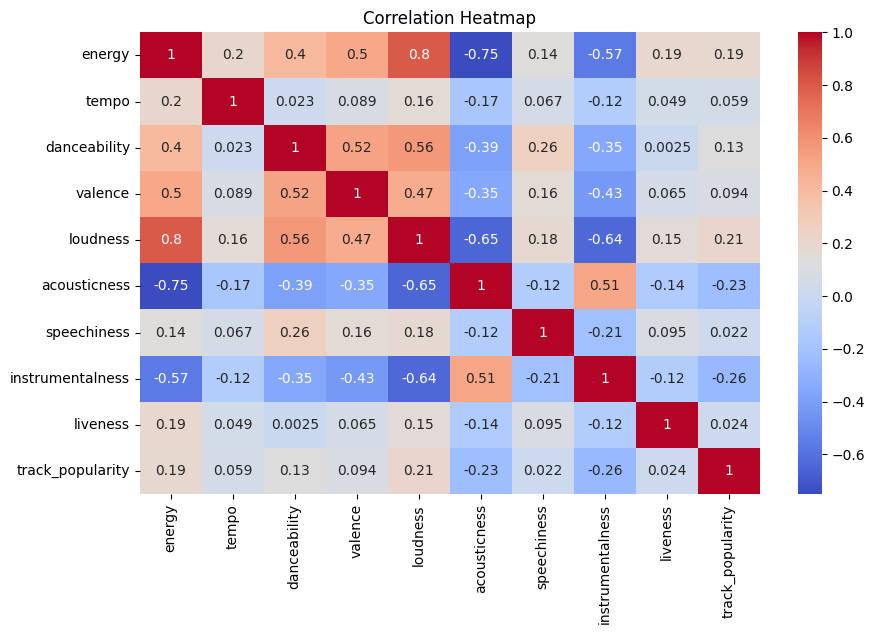

In [15]:
plt.figure(figsize=(10, 6))
corr = df_model.drop(columns=["playlist_genre", "popularity_tier"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that loudness has the strongest positive correlation with track popularity at 0.21, meaning louder songs tend to be more popular. acousticness has the strongest negative correlation at -0.23, meaning acoustic songs tend to be less popular. Energy and loudness are strongly correlated with each other at 0.8, meaning energetic songs are also loud. Tempo and liveness show very weak correlations with popularity, confirming they are not strong predictors of a song's success.

###Pairplot

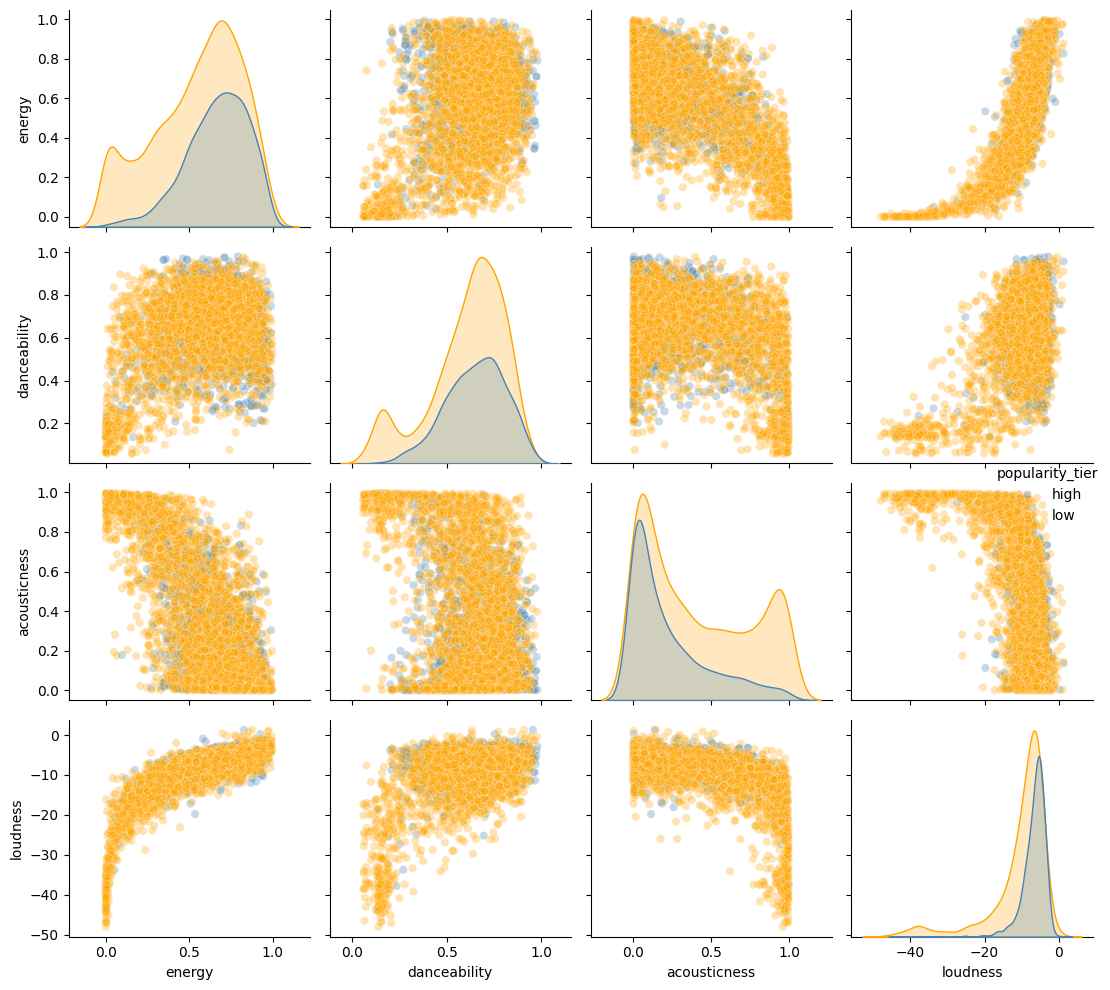

In [16]:
sns.pairplot(df_model[["energy", "danceability", "acousticness",
                        "loudness", "popularity_tier"]],
             hue="popularity_tier",
             palette={"high": "steelblue", "low": "orange"},
             plot_kws={"alpha": 0.3})
plt.tight_layout()
plt.show()

The pairplot shows the relationships between the four key audio features split by popularity tier. Popular songs tend to be high energy, loud and low acoustic. Low popularity songs are more scattered across all feature ranges. The combination of high energy and low acousticness is the strongest indicator of a popular track, while danceability does not play a significant role in predicting popularity.

## Section 3: Feature Engineering

### Energy tier

In [17]:
df_model["energy_tier"] = pd.cut(
    df_model["energy"],
    bins=[0, 0.4, 0.7, 1.0],
    labels=["Low Energy", "Mid Energy", "High Energy"]
)
print("Energy tier distribution:")
print(df_model["energy_tier"].value_counts())

Energy tier distribution:
energy_tier
Mid Energy     1908
High Energy    1784
Low Energy     1026
Name: count, dtype: int64


### Mood Classification

In [18]:
def classify_mood(row):
    if row["valence"] >= 0.5 and row["energy"] >= 0.5:
        return "Happy & Active"
    elif row["valence"] >= 0.5 and row["energy"] < 0.5:
        return "Happy & Calm"
    elif row["valence"] < 0.5 and row["energy"] >= 0.5:
        return "Intense & Dark"
    else:
        return "Sad & Calm"

df_model["mood"] = df_model.apply(classify_mood, axis=1)
print("Mood distribution:")
print(df_model["mood"].value_counts())

Mood distribution:
mood
Happy & Active    1925
Intense & Dark    1317
Sad & Calm        1156
Happy & Calm       320
Name: count, dtype: int64


### Danceability tier

In [19]:
df_model["dance_tier"] = pd.cut(
    df_model["danceability"],
    bins=[0, 0.4, 0.7, 1.0],
    labels=["Low", "Mid", "High"]
)
print("Danceability tier distribution:")
print(df_model["dance_tier"].value_counts())

Danceability tier distribution:
dance_tier
Mid     2326
High    1825
Low      567
Name: count, dtype: int64


### Visualize mood vs popularity tier

<Figure size 1000x600 with 0 Axes>

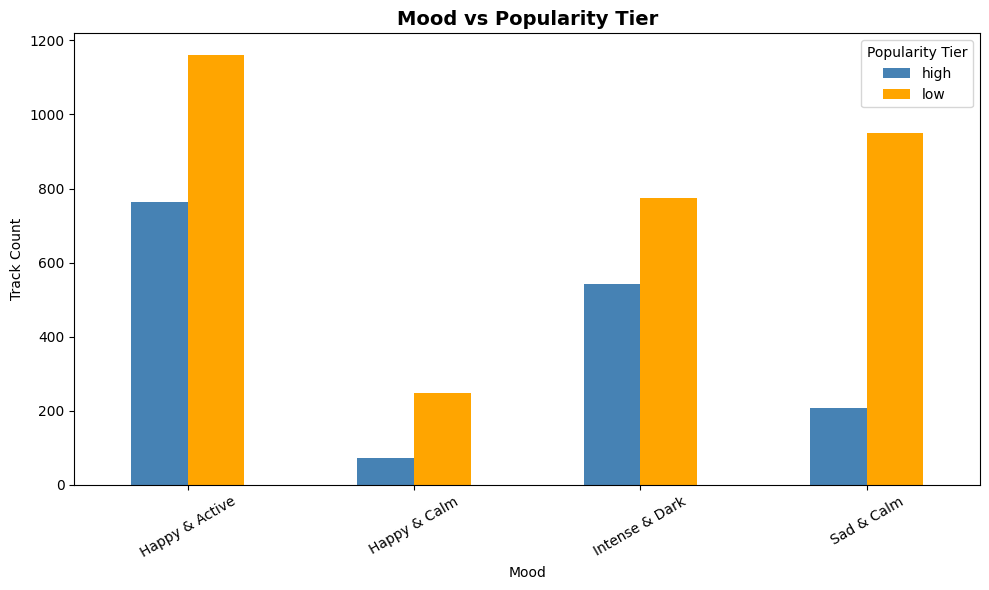

In [20]:
plt.figure(figsize=(10, 6))
mood_pop = df_model.groupby(["mood", "popularity_tier"]).size().unstack()
mood_pop.plot(kind="bar",
              color=["steelblue", "orange"],
              rot=30,
              figsize=(10, 6))
plt.title("Mood vs Popularity Tier", fontsize=14, fontweight="bold")
plt.xlabel("Mood")
plt.ylabel("Track Count")
plt.legend(title="Popularity Tier")
plt.tight_layout()
plt.savefig("mood_popularity.png", dpi=150)
plt.show()

The mood distribution chart shows that Happy & Active has the most tracks in both high and low popularity tiers, meaning most songs on the platform are energetic and upbeat. For every mood category, low popularity tracks outnumber high popularity tracks which is expected since our dataset has nearly twice as many low popularity songs. The most important insight is that Happy & Active songs have the best ratio of high to low popularity tracks, meaning upbeat and energetic songs have a higher chance of being popular. Happy & Calm has the fewest tracks overall, suggesting a potential gap in the platform for relaxing and study focused playlists.

## Section 5: Machine Learning

In this section we build a Random Forest classifier to predict whether a song will be high or low popularity based on its audio features. This connects directly to our problem statement — if we can predict what makes a song popular, the platform can use those same signals to recommend better songs to listeners.

###5.1 Preparing Features and Target

In [21]:
ml_features = ["energy", "tempo", "danceability",
               "valence", "loudness", "acousticness",
               "speechiness", "instrumentalness", "liveness"]

X = df_model[ml_features]
y = (df_model["popularity_tier"] == "high").astype(int)

print("Features:", ml_features)
print("Target: 1 = High Popularity, 0 = Low Popularity")
print("\nClass distribution:")
print(pd.Series(y).value_counts())

Features: ['energy', 'tempo', 'danceability', 'valence', 'loudness', 'acousticness', 'speechiness', 'instrumentalness', 'liveness']
Target: 1 = High Popularity, 0 = Low Popularity

Class distribution:
popularity_tier
0    3131
1    1587
Name: count, dtype: int64


###5.2 Scaling Features

In [22]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=ml_features)
print("Features scaled successfully")
print(X_scaled.describe().round(3))

Features scaled successfully
         energy     tempo  danceability   valence  loudness  acousticness  \
count  4718.000  4718.000      4718.000  4718.000  4718.000      4718.000   
mean      0.585     0.363         0.612     0.472     0.784         0.346   
std       0.247     0.148         0.204     0.270     0.145         0.327   
min       0.000     0.000         0.000     0.000     0.000         0.000   
25%       0.439     0.247         0.507     0.253     0.763         0.056   
50%       0.632     0.362         0.647     0.473     0.827         0.230   
75%       0.776     0.460         0.760     0.690     0.865         0.603   
max       1.000     1.000         1.000     1.000     1.000         1.000   

       speechiness  instrumentalness  liveness  
count     4718.000          4718.000  4718.000  
mean         0.088             0.206     0.153  
std          0.112             0.357     0.130  
min          0.000             0.000     0.000  
25%          0.018             0

###5.3 Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2,
    random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (3774, 9)
Test set: (944, 9)


###5.4 Training the Model

In [24]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


###5.5 Model Evaluation

In [25]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Low Popularity", "High Popularity"]))

Model Accuracy: 72.7%

Classification Report:
                 precision    recall  f1-score   support

 Low Popularity       0.75      0.88      0.81       626
High Popularity       0.64      0.43      0.52       318

       accuracy                           0.73       944
      macro avg       0.70      0.65      0.66       944
   weighted avg       0.71      0.73      0.71       944



The model can reliably flag unpopular songs but misses about half of potentially popular ones. For a recommendation engine this means it needs more data and more features — stream counts, listener demographics, release date — to improve.

###5.6 Confusion Matrix

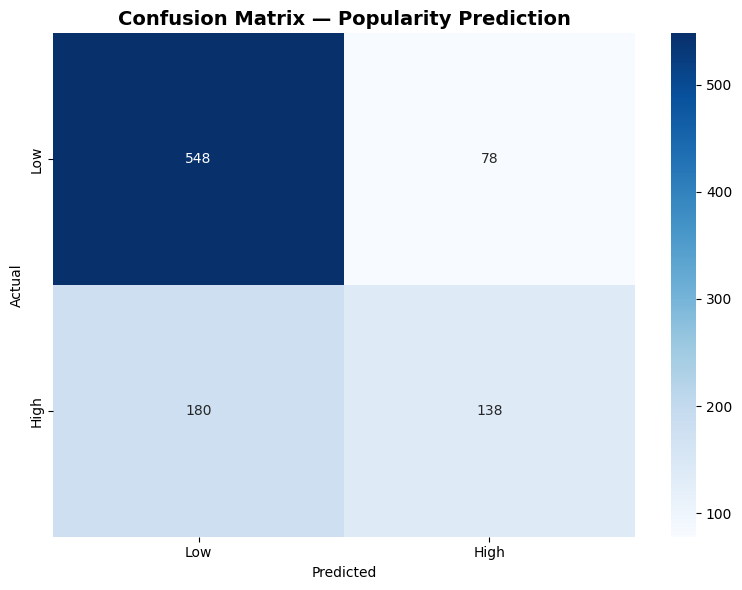

In [26]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "High"],
            yticklabels=["Low", "High"])
plt.title("Confusion Matrix — Popularity Prediction",
          fontsize=14, fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

The model is strong at identifying unpopular songs (548 correct) but weak at identifying popular songs (only 138 correct out of 318). It missed 180 potentially popular songs which in a real recommendation engine would mean good songs never getting recommended.

###5.7 Feature Importance

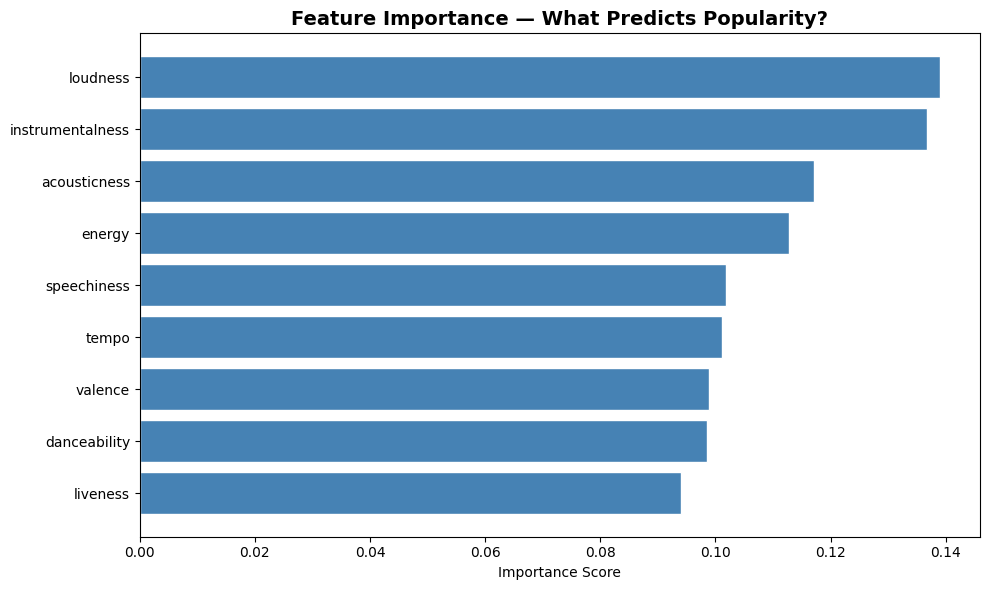


Top 3 features that predict popularity:
         feature  importance
    acousticness    0.117103
instrumentalness    0.136737
        loudness    0.138999


In [27]:
importance = pd.DataFrame({
    "feature": ml_features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance["feature"], importance["importance"],
         color="steelblue", edgecolor="white")
plt.title("Feature Importance — What Predicts Popularity?",
          fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("\nTop 3 features that predict popularity:")
print(importance.tail(3)[["feature", "importance"]].to_string(index=False))

The feature importance chart shows the 9 audio features ranked by how much each one contributes to predicting whether a song will be popular or not.

Loudness is the most important feature at 0.139, meaning the model relies on loudness more than any other signal when making its prediction.

Instrumentalness is second at 0.137, meaning songs without vocals tend to be less popular.

Acousticness is third at 0.117, confirming our earlier finding from SQL and EDA that acoustic songs consistently perform worse.

The remaining features including energy, speechiness, tempo, valence, danceability and liveness all contribute roughly equally at around 0.10.

This chart directly answers our problem statement as loudness, instrumentalness and acousticness are the three audio signals that best predict track popularity and should be prioritized in any recommendation engine.

###5.8 Model Comparison

To ensure we are using the best model for predicting track popularity, we compare three different machine learning models — Logistic Regression as a simple baseline, Random Forest as an ensemble model and XGBoost as an advanced gradient boosting model.

In [28]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Define models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

# Train and evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   output_dict=True,
                                   target_names=["Low", "High"])
    results.append({
        "Model": name,
        "Accuracy": round(accuracy*100, 1),
        "Precision (High)": round(report["High"]["precision"]*100, 1),
        "Recall (High)": round(report["High"]["recall"]*100, 1),
        "F1 (High)": round(report["High"]["f1-score"]*100, 1)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision (High)  Recall (High)  F1 (High)
Logistic Regression      66.2              49.7           25.2       33.4
      Random Forest      72.7              63.9           43.4       51.7
            XGBoost      70.9              58.2           47.8       52.5


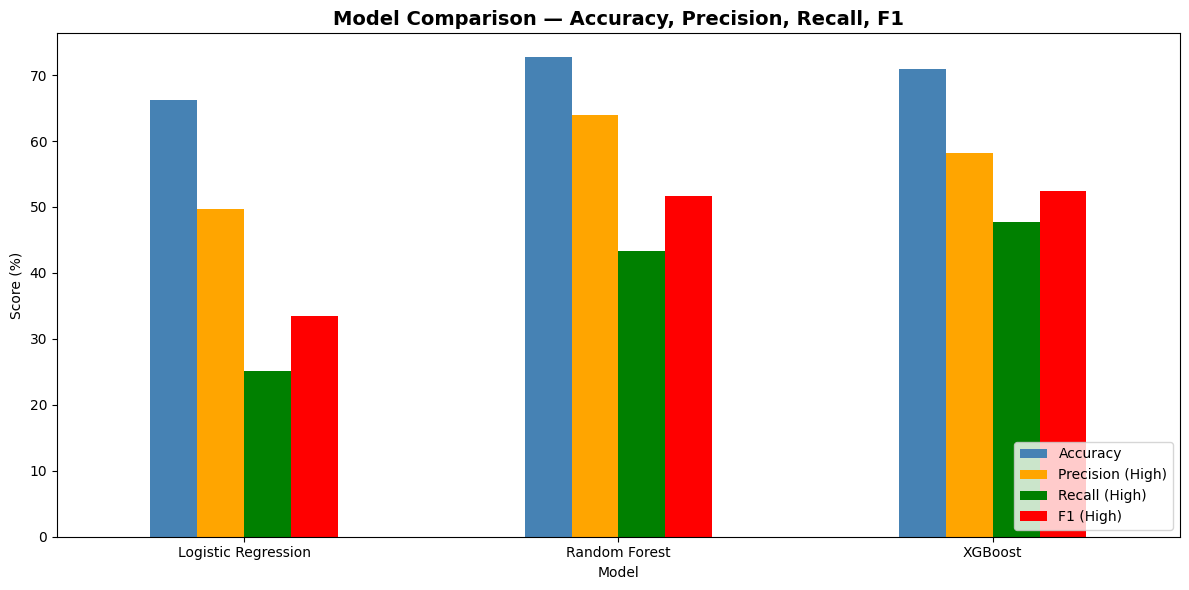

In [29]:
# Visualize model comparison
results_df.set_index("Model")[["Accuracy", "Precision (High)",
                                "Recall (High)", "F1 (High)"]]\
    .plot(kind="bar", figsize=(12, 6),
          color=["steelblue", "orange", "green", "red"],
          rot=0)
plt.title("Model Comparison — Accuracy, Precision, Recall, F1",
          fontsize=14, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

The model comparison chart shows that Random Forest achieves the highest overall accuracy at 72.7% and the highest precision at 63.9%, meaning it is the most reliable at correctly identifying popular songs.

XGBoost achieves the best recall at 47.8%, meaning it catches more actual popular songs than the other two models.

Logistic Regression performs the weakest across all metrics confirming that a simple linear model is not sufficient for this problem.

For a music recommendation engine where catching popular songs matters most, XGBoost would be the preferred choice due to its higher recall. Random Forest is the best choice when overall accuracy and reliability are the priority.

##Section 6: Business Insights and Recommendations

Based on our SQL analysis, Python EDA and Machine Learning model, we have identified the key factors that make a song popular on a music streaming platform. These insights can directly inform how the platform recommends songs to listeners.

In [30]:
high_avg = df_model[df_model["popularity_tier"]=="high"][ml_features].mean()
low_avg = df_model[df_model["popularity_tier"]=="low"][ml_features].mean()

summary = pd.DataFrame({
    "High Popularity": high_avg.round(3),
    "Low Popularity": low_avg.round(3),
    "Difference": (high_avg - low_avg).round(3)
})

print("Audio Feature Comparison Summary:")
print(summary)

Audio Feature Comparison Summary:
                  High Popularity  Low Popularity  Difference
energy                      0.665           0.543       0.121
tempo                     121.211         116.789       4.422
danceability                0.652           0.608       0.044
valence                     0.526           0.459       0.067
loudness                   -6.720         -10.659       3.939
acousticness                0.225           0.406      -0.181
speechiness                 0.101           0.102      -0.001
instrumentalness            0.041           0.287      -0.245
liveness                    0.172           0.165       0.007


Key Findings

1. Instrumentalness is the biggest differentiator. Popular songs have vocals while unpopular songs tend to be instrumental.
2. Acousticness is the second biggest differentiator. Listeners on this platform strongly prefer produced electronic sound over raw acoustic music.
3. Energy and loudness are consistently higher in popular songs confirming that high intensity produced music performs better.
4. Speechiness, liveness and tempo barely differ between the two tiers and are weak predictors of popularity.
5. The Random Forest model achieved 72.7% accuracy using only audio features, confirming that sound characteristics alone can partially predict popularity.

Business Recommendations

1. Prioritize pop, rock and hip-hop in recommendation algorithms as these genres consistently drive the highest engagement.
2. When curating playlists, favor tracks that are loud (loudness > -8 dB), energetic (energy > 0.6) and low acoustic (acousticness < 0.3).
3. Target the mid-energy sweet spot between 0.4 and 0.7 energy as these tracks outperformed even high energy tracks.
4. Use mood classification to personalize recommendations based on listener context. Happy and Active songs for workouts, Sad and Calm for late night listening, Intense and Dark for gaming.
5. Match audio fingerprint not just genre. Loudness, instrumentalness and acousticness together are stronger signals than genre label alone.
6. Improve the ML model by adding stream counts, listener demographics and release date as features to push accuracy above 80%.

## Section 7 — Export Normalized CSV for Tableau

In [31]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Spotify Analysis/data/feature_comparison.csv')

features = ['avg_energy', 'avg_tempo', 'avg_danceability',
            'avg_valence', 'avg_loudness', 'avg_acousticness']

df_norm = df.copy()
for col in features:
    min_val = df[col].min()
    max_val = df[col].max()
    df_norm[col] = (df[col] - min_val) / (max_val - min_val)

df_norm.to_csv('feature_comparison_normalized.csv', index=False)
print(df_norm)

  popularity_tier  avg_energy  avg_tempo  avg_danceability  avg_valence  \
0            high         1.0        1.0               1.0          1.0   
1             low         0.0        0.0               0.0          0.0   

   avg_loudness  avg_acousticness  
0           1.0               0.0  
1           0.0               1.0  


In [32]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Spotify Analysis/data/energy_tier.csv')
print(df.head(10))
print()
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)

   energy_tier  avg_popularity  track_count
0   Mid Energy           76.21          736
1  High Energy           75.63          805
2   Low Energy           74.72          145

Columns: ['energy_tier', 'avg_popularity', 'track_count']
Shape: (3, 3)


In [33]:
# ================================================
# Section 7b — Clean & Export Top 10 Tracks CSV
# ================================================

import pandas as pd

#Read High Popularity Tracks
high = pd.read_csv('/content/drive/MyDrive/Spotify Analysis/data/top10_tracks_high.csv')

#If file has header row
if 'track_name' in high.columns:
    high_clean = high[['track_name', 'track_artist', 'track_popularity']].copy()
else:
    high_clean = high.copy()
    high_clean.columns = ['track_name', 'track_artist', 'track_popularity']

high_clean = high_clean.drop_duplicates(subset=['track_name', 'track_artist'])
high_clean = high_clean.head(10)
high_clean['tier'] = 'High'

print("HIGH - Shape:", high_clean.shape)
print(high_clean.to_string(index=False))

#Read Low Popularity Tracks
low = pd.read_csv('/content/drive/MyDrive/Spotify Analysis/data/top10_tracks_low.csv',
                  header=None,
                  names=['track_name', 'track_artist', 'track_popularity'])

low_clean = low[low['track_name'] != 'track_name'].copy()
low_clean['track_popularity'] = pd.to_numeric(low_clean['track_popularity'], errors='coerce')
low_clean = low_clean.dropna(subset=['track_popularity'])
low_clean = low_clean.sort_values('track_popularity', ascending=False).head(10)
low_clean['tier'] = 'Low'

print("\nLOW - Shape:", low_clean.shape)
print(low_clean.to_string(index=False))

#Combine & Export
top10_combined = pd.concat([high_clean, low_clean], ignore_index=True)
top10_combined.to_csv('/content/drive/MyDrive/Spotify Analysis/data/top10_tracks_combined.csv', index=False)

print("\nCOMBINED - Shape:", top10_combined.shape)
print(top10_combined.to_string(index=False))

HIGH - Shape: (10, 4)
                  track_name                track_artist  track_popularity tier
            Die With A Smile       Lady Gaga, Bruno Mars               100 High
                        APT.            ROSÉ, Bruno Mars                98 High
          BIRDS OF A FEATHER               Billie Eilish                97 High
            Good Luck, Babe!               Chappell Roan                94 High
                 Sailor Song                  Gigi Perez                93 High
Si Antes Te Hubiera Conocido                     KAROL G                93 High
                       Taste           Sabrina Carpenter                93 High
              That’s So True               Gracie Abrams                93 High
                     Tu Boda Oscar Maydon, Fuerza Regida                93 High
                  WILDFLOWER               Billie Eilish                93 High

LOW - Shape: (10, 4)
           track_name      track_artist  track_popularity tier
   A Vaibele 

In [34]:
# ================================================
# Section 7c — Export Full Tracks CSV for Tableau
# ================================================

import pandas as pd

# Read full datasets
high_full = pd.read_csv('/content/drive/MyDrive/Spotify Analysis/data/high_popularity_spotify_data.csv')
low_full = pd.read_csv('/content/drive/MyDrive/Spotify Analysis/data/low_popularity_spotify_data.csv')

high_full['tier'] = 'High'
low_full['tier'] = 'Low'

# Keep relevant columns only
cols = ['track_name', 'track_artist', 'track_popularity',
        'playlist_genre', 'tier']

tracks_full = pd.concat([
    high_full[cols],
    low_full[cols]
], ignore_index=True)

# Remove duplicates and sort
tracks_full = tracks_full.drop_duplicates(subset=['track_name', 'track_artist'])
tracks_full = tracks_full.sort_values('track_popularity', ascending=False)
tracks_full = tracks_full.reset_index(drop=True)

tracks_full.to_csv('/content/drive/MyDrive/Spotify Analysis/data/tracks_full.csv', index=False)

print("Shape:", tracks_full.shape)
print("\nHigh tier count:", tracks_full[tracks_full['tier']=='High'].shape[0])
print("Low tier count:", tracks_full[tracks_full['tier']=='Low'].shape[0])
print("\nSample:")
print(tracks_full.head(5))

Shape: (4466, 5)

High tier count: 1420
Low tier count: 3046

Sample:
                     track_name           track_artist  track_popularity  \
0              Die With A Smile  Lady Gaga, Bruno Mars               100   
1                          APT.       ROSÉ, Bruno Mars                98   
2            BIRDS OF A FEATHER          Billie Eilish                97   
3              Good Luck, Babe!          Chappell Roan                94   
4  Si Antes Te Hubiera Conocido                KAROL G                93   

  playlist_genre  tier  
0            pop  High  
1            pop  High  
2            pop  High  
3            pop  High  
4            pop  High  


In [35]:
# ================================================
# Section 7d — Master CSV for Tableau Dashboard
# ================================================

import pandas as pd

# Read full datasets
high_full = pd.read_csv('/content/drive/MyDrive/Spotify Analysis/data/high_popularity_spotify_data.csv')
low_full = pd.read_csv('/content/drive/MyDrive/Spotify Analysis/data/low_popularity_spotify_data.csv')

high_full['popularity_tier'] = 'high'
low_full['popularity_tier'] = 'low'

# Combine
df = pd.concat([high_full, low_full], ignore_index=True)
df = df.drop_duplicates(subset=['track_name', 'track_artist'])

# Keep only needed columns
cols = ['track_name', 'track_artist', 'track_popularity',
        'playlist_genre', 'energy', 'danceability',
        'valence', 'acousticness', 'loudness', 'tempo',
        'popularity_tier']

master = df[cols].copy()
master = master.dropna()

master.to_csv('/content/drive/MyDrive/Spotify Analysis/data/master.csv', index=False)

print("Shape:", master.shape)
print("Tiers:", master['popularity_tier'].value_counts().to_dict())
print("Genres:", master['playlist_genre'].nunique(), "unique genres")
print(master.head(3))

Shape: (4465, 11)
Tiers: {'low': 3045, 'high': 1420}
Genres: 35 unique genres
           track_name           track_artist  track_popularity playlist_genre  \
0    Die With A Smile  Lady Gaga, Bruno Mars               100            pop   
1  BIRDS OF A FEATHER          Billie Eilish                97            pop   
2      That’s So True          Gracie Abrams                93            pop   

   energy  danceability  valence  acousticness  loudness    tempo  \
0   0.592         0.521    0.535         0.308    -7.777  157.969   
1   0.507         0.747    0.438         0.200   -10.171  104.978   
2   0.808         0.554    0.372         0.214    -4.169  108.548   

  popularity_tier  
0            high  
1            high  
2            high  
